In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sms
from datetime import datetime

In [2]:
df=pd.read_csv('TATAMOTORS_data.csv')

In [3]:
df.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
1,2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2,2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428


In [4]:
df.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume
1230,2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443
1231,2022-11-10,420.500000,420.549988,409.200012,412.200012,412.200012,26251660
1232,2022-11-11,420.000000,425.500000,414.700012,423.500000,423.500000,19296401


In [5]:
df.set_index('Date', inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407
...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443


In [6]:
# make it datetime format
df.index = pd.to_datetime(df.index, format = '%Y/%m/%d')

In [7]:
df.head(3)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1233 entries, 2017-11-15 to 2022-11-11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1233 non-null   float64
 1   High       1233 non-null   float64
 2   Low        1233 non-null   float64
 3   Close      1233 non-null   float64
 4   Adj Close  1233 non-null   float64
 5   Volume     1233 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 67.4 KB


In [9]:
df.shape

(1233, 6)

In [10]:
df.drop(['Adj Close'], axis=1, inplace=True)

In [11]:
df.corr()

,Open,High,Low,Close,Volume
Open,1.000000,0.999341,0.999269,0.998682,-0.318062
High,0.999341,1.000000,0.999138,0.999504,-0.302008
Low,0.999269,0.999138,1.000000,0.999417,-0.324328
Close,0.998682,0.999504,0.999417,1.000000,-0.309878
Volume,-0.318062,-0.302008,-0.324328,-0.309878,1.000000


In [12]:
import seaborn as sns

            Open      High       Low     Close    Volume
Open    1.000000  0.999341  0.999269  0.998682 -0.318062
High    0.999341  1.000000  0.999138  0.999504 -0.302008
Low     0.999269  0.999138  1.000000  0.999417 -0.324328
Close   0.998682  0.999504  0.999417  1.000000 -0.309878
Volume -0.318062 -0.302008 -0.324328 -0.309878  1.000000


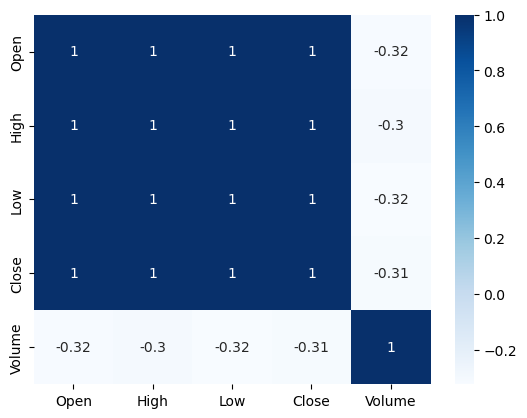

In [13]:
print(df.corr())
  
# plotting correlation heatmap
dataplot = sns.heatmap(df.corr(), cmap="Blues" ,annot=True)
  
# displaying heatmap
plt.show()

<AxesSubplot:xlabel='Date'>

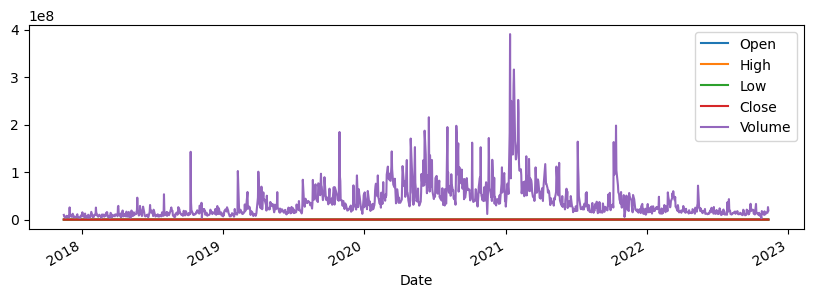

In [14]:
df.plot(figsize=(10,3))

<AxesSubplot:xlabel='Date'>

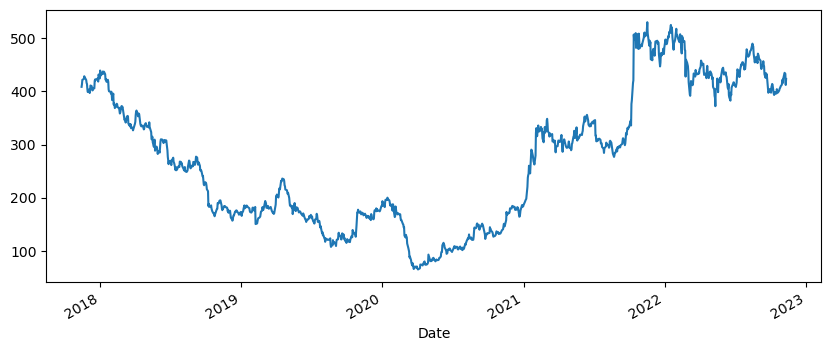

In [15]:
df['Close'].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

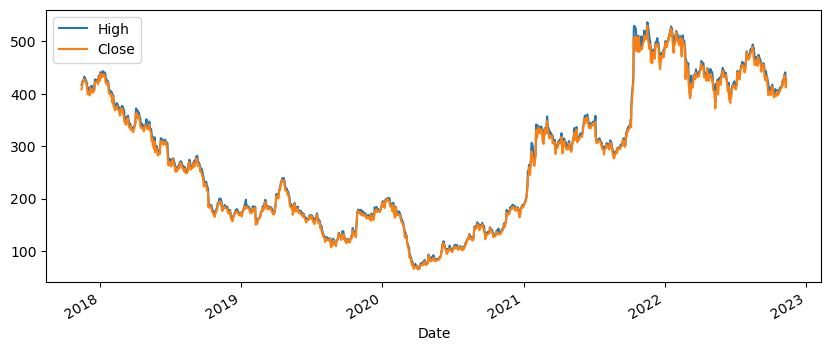

In [16]:
df[['High','Close']].plot(figsize=(10,4))

<AxesSubplot:xlabel='Date'>

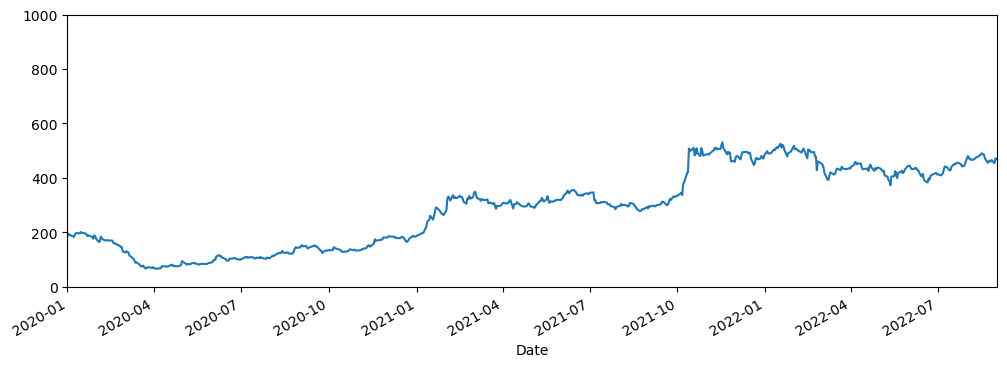

In [17]:
df['Close'].plot(xlim=['2020-01-01','2022-09-01'],ylim=[0,1000],figsize=(12,4))

In [18]:
df.index

DatetimeIndex(['2017-11-15', '2017-11-16', '2017-11-17', '2017-11-20',
               '2017-11-21', '2017-11-22', '2017-11-23', '2017-11-24',
               '2017-11-27', '2017-11-28',
               ...
               '2022-10-28', '2022-10-31', '2022-11-01', '2022-11-02',
               '2022-11-03', '2022-11-04', '2022-11-07', '2022-11-09',
               '2022-11-10', '2022-11-11'],
              dtype='datetime64[ns]', name='Date', length=1233, freq=None)

# Time Resampling

In [19]:
df.resample(rule='A').min() 
#It gives us MIN values of all parameters in each year.

,Open,High,Low,Close,Volume
Date,,,,,
2017-12-31,398.000000,404.000000,389.299988,397.049988,3673355
2018-12-31,155.000000,159.500000,154.649994,157.100006,3820313
2019-12-31,108.900002,111.599998,106.000000,107.699997,6141180
2020-12-31,66.500000,66.900002,63.500000,65.300003,11749453
2021-12-31,184.949997,187.000000,184.500000,186.500000,5531940
2022-12-31,382.000000,384.649994,366.200012,372.299988,2871205


In [20]:
df.resample(rule='A').max()  
#It gives us MAX values of all parameters in each year.

,Open,High,Low,Close,Volume
Date,,,,,
2017-12-31,428.600006,433.450012,424.500000,431.850006,25646262
2018-12-31,440.399994,443.500000,433.000000,439.299988,142760251
2019-12-31,235.000000,239.350006,231.699997,236.250000,184435614
2020-12-31,199.500000,201.699997,196.899994,200.350006,215476711
2021-12-31,531.450012,536.700012,520.250000,530.150024,390577839
2022-12-31,527.900024,528.500000,512.000000,525.000000,71425747


<AxesSubplot:xlabel='Date'>

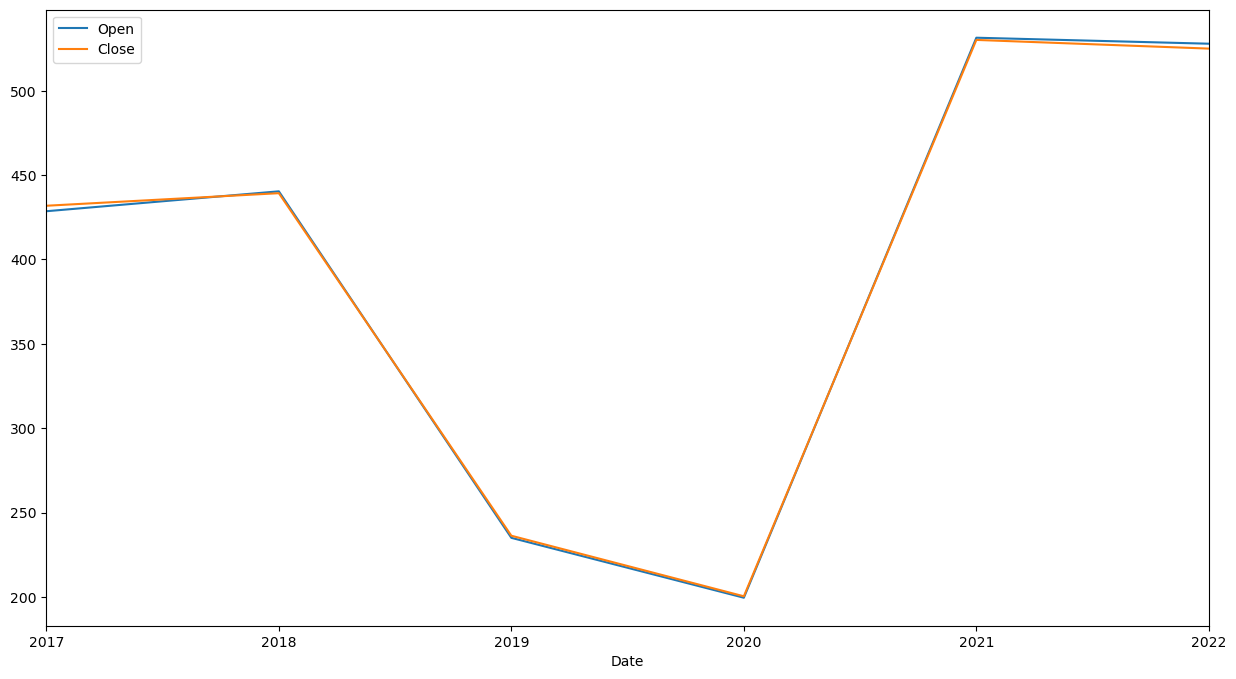

In [21]:
##rule = A : year end frequency
df.resample(rule='A').max()[['Open','Close']].plot(figsize=(15,8))
# PLOT open max price over the year

In [22]:
df.resample(rule='QS').max()
##RULE QS : quaterly start frequency--> after three months

,Open,High,Low,Close,Volume
Date,,,,,
2017-10-01,428.600006,433.450012,424.500000,431.850006,25646262
2018-01-01,440.399994,443.500000,433.000000,439.299988,25294860
2018-04-01,362.600006,372.350006,359.799988,364.100006,46104103
2018-07-01,277.250000,282.000000,272.899994,277.399994,53282545
2018-10-01,230.000000,232.800003,225.800003,229.350006,142760251
2019-01-01,195.399994,198.350006,187.800003,194.050003,102256857
2019-04-01,235.000000,239.350006,231.699997,236.250000,100834335
2019-07-01,170.000000,172.350006,166.300003,170.000000,96568372
2019-10-01,184.000000,187.899994,181.550003,185.149994,184435614


<AxesSubplot:xlabel='Date'>

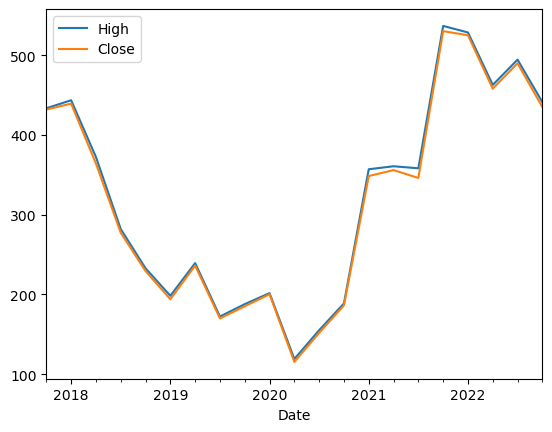

In [23]:
##RULE QS : quaterly start frequency--> after three months 
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='QS').max()[['High','Close']].plot()

In [24]:
##RULE BA : Business End Frequency
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='BA').max()

,Open,High,Low,Close,Volume
Date,,,,,
2017-12-29,428.600006,433.450012,424.500000,431.850006,25646262
2018-12-31,440.399994,443.500000,433.000000,439.299988,142760251
2019-12-31,235.000000,239.350006,231.699997,236.250000,184435614
2020-12-31,199.500000,201.699997,196.899994,200.350006,215476711
2021-12-31,531.450012,536.700012,520.250000,530.150024,390577839
2022-12-30,527.900024,528.500000,512.000000,525.000000,71425747


In [25]:
df.resample(rule='BQS').max()

,Open,High,Low,Close,Volume
Date,,,,,
2017-10-02,428.600006,433.450012,424.500000,431.850006,25646262
2018-01-01,440.399994,443.500000,433.000000,439.299988,25294860
2018-04-02,362.600006,372.350006,359.799988,364.100006,46104103
2018-07-02,277.250000,282.000000,272.899994,277.399994,53282545
2018-10-01,230.000000,232.800003,225.800003,229.350006,142760251
2019-01-01,195.399994,198.350006,187.800003,194.050003,102256857
2019-04-01,235.000000,239.350006,231.699997,236.250000,100834335
2019-07-01,170.000000,172.350006,166.300003,170.000000,96568372
2019-10-01,184.000000,187.899994,181.550003,185.149994,184435614


<AxesSubplot:xlabel='Date'>

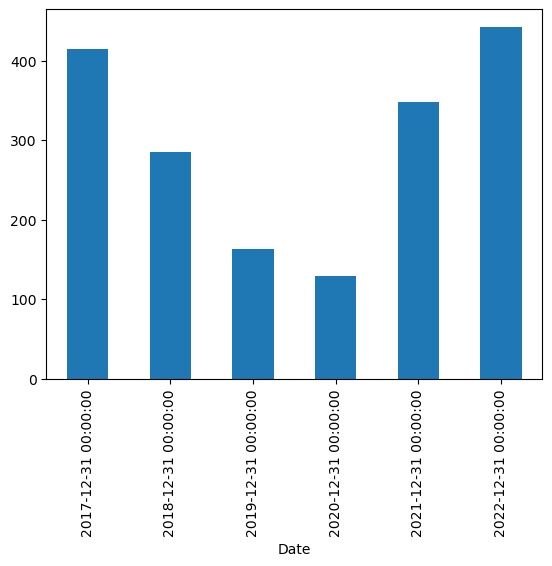

In [26]:
##plotting
df['Close'].resample(rule='A').mean().plot(kind='bar')

<AxesSubplot:xlabel='Date'>

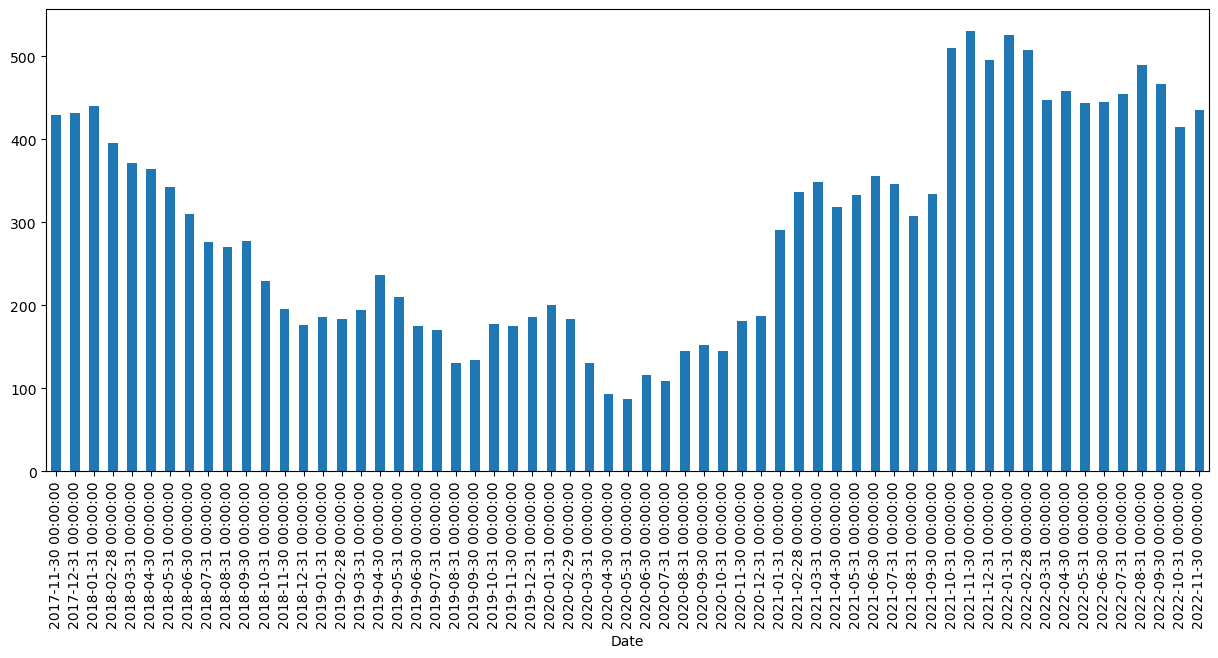

In [27]:
# RULE M : monthly data
df['Close'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))

In [28]:
df['Close'].rolling(11).mean().head(20)

Date
2017-11-15           NaN
2017-11-16           NaN
2017-11-17           NaN
2017-11-20           NaN
2017-11-21           NaN
2017-11-22           NaN
2017-11-23           NaN
2017-11-24           NaN
2017-11-27           NaN
2017-11-28           NaN
2017-11-29    420.254547
2017-11-30    419.845456
2017-12-01    418.522727
2017-12-04    416.872728
2017-12-05    414.986364
2017-12-06    412.513636
2017-12-07    410.095453
2017-12-08    408.722726
2017-12-11    407.327271
2017-12-12    406.004544
Name: Close, dtype: float64

In [29]:
df['Close'].rolling(11).max().head(20)

Date
2017-11-15           NaN
2017-11-16           NaN
2017-11-17           NaN
2017-11-20           NaN
2017-11-21           NaN
2017-11-22           NaN
2017-11-23           NaN
2017-11-24           NaN
2017-11-27           NaN
2017-11-28           NaN
2017-11-29    428.600006
2017-11-30    428.600006
2017-12-01    428.600006
2017-12-04    428.600006
2017-12-05    428.600006
2017-12-06    428.600006
2017-12-07    426.250000
2017-12-08    425.500000
2017-12-11    421.399994
2017-12-12    415.950012
Name: Close, dtype: float64

In [30]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,6191428
2017-11-20,421.000000,425.700012,420.100006,423.000000,4051153
2017-11-21,424.450012,430.000000,422.500000,424.250000,6745407


In [31]:
# simple moving average
df['Close:2 days rolling']=df['Close'].rolling(2).mean()
df['Close:5 days rolling']=df['Close'].rolling(5).mean()
df['Close:7 days rolling']=df['Close'].rolling(7).mean()
df['Close:10 days rolling']=df['Close'].rolling(10).mean()
df['Close:30 days rolling']=df['Close'].rolling(30).mean()
df['Close:50 days rolling']=df['Close'].rolling(50).mean()

In [32]:
df.head(31)

,Open,High,Low,Close,Volume,Close:2 days rolling,Close:5 days rolling,Close:7 days rolling,Close:10 days rolling,Close:30 days rolling,Close:50 days rolling
Date,,,,,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,9867270,NaN,NaN,NaN,NaN,NaN,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,6291441,411.050003,NaN,NaN,NaN,NaN,NaN
2017-11-17,419.450012,423.450012,417.000000,421.799988,6191428,417.625000,NaN,NaN,NaN,NaN,NaN
2017-11-20,421.000000,425.700012,420.100006,423.000000,4051153,422.399994,NaN,NaN,NaN,NaN,NaN
2017-11-21,424.450012,430.000000,422.500000,424.250000,6745407,423.625000,418.229999,NaN,NaN,NaN,NaN
2017-11-22,425.450012,433.000000,424.500000,428.600006,7899417,426.425003,422.220001,NaN,NaN,NaN,NaN
2017-11-23,428.600006,431.049988,422.450012,426.250000,7374216,427.425003,424.779999,420.857143,NaN,NaN,NaN
2017-11-24,427.000000,429.950012,424.250000,425.500000,5108182,425.875000,425.520001,423.264287,NaN,NaN,NaN
2017-11-27,423.000000,424.750000,417.799988,421.399994,7946028,423.449997,425.200000,424.399998,NaN,NaN,NaN


<AxesSubplot:xlabel='Date'>

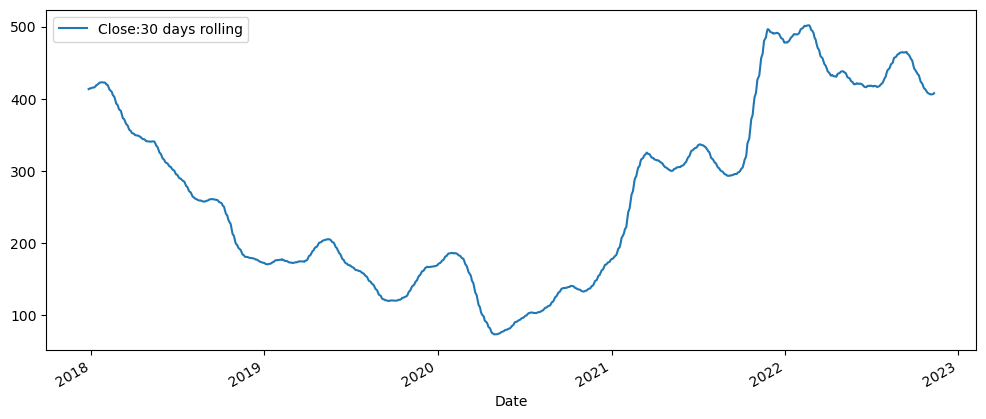

In [33]:
df[['Close:30 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

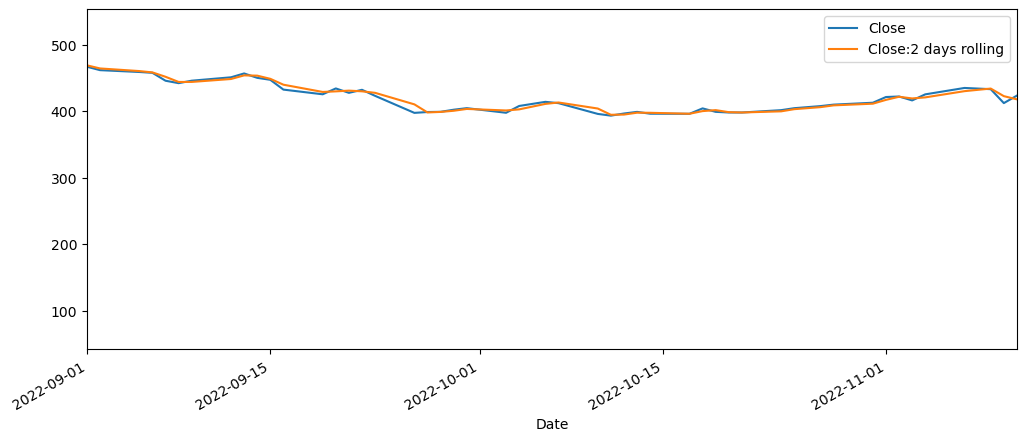

In [34]:
df[['Close','Close:2 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

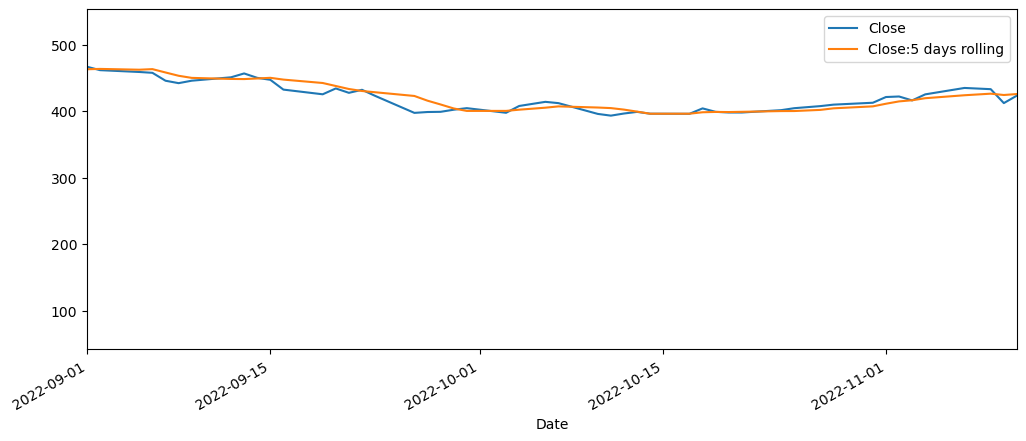

In [35]:
df[['Close','Close:5 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

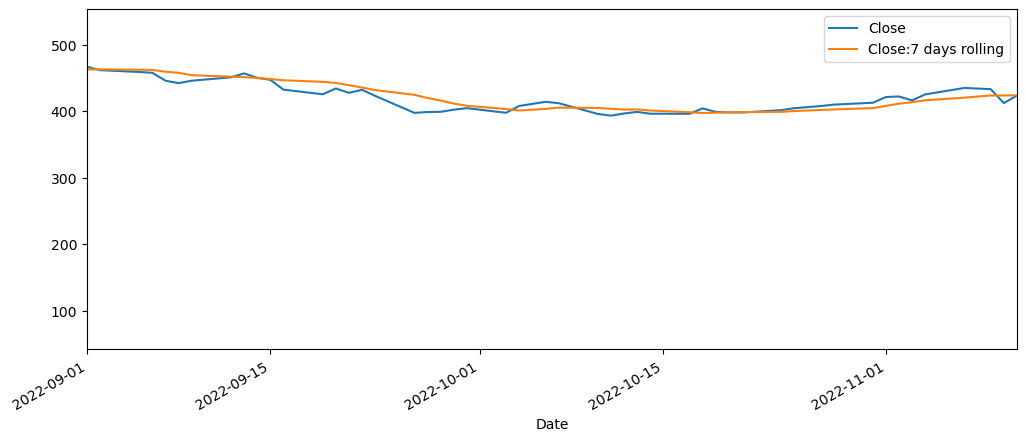

In [36]:
df[['Close','Close:7 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

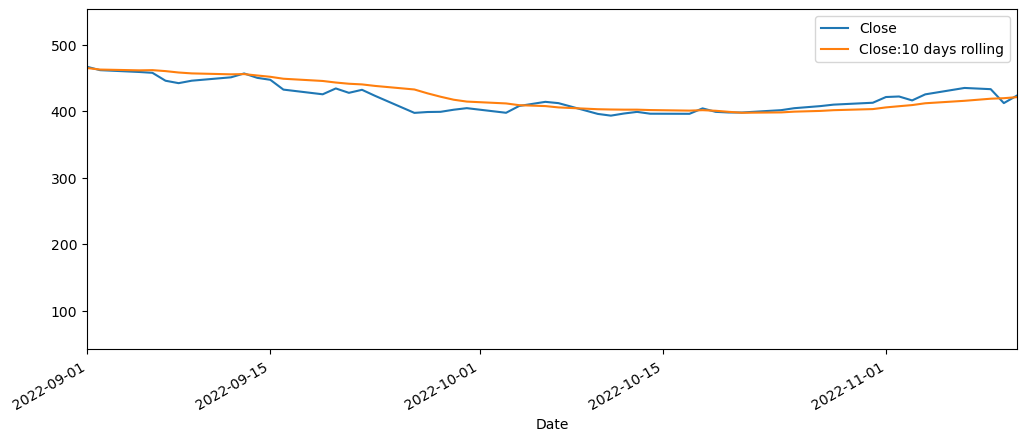

In [37]:
df[['Close','Close:10 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

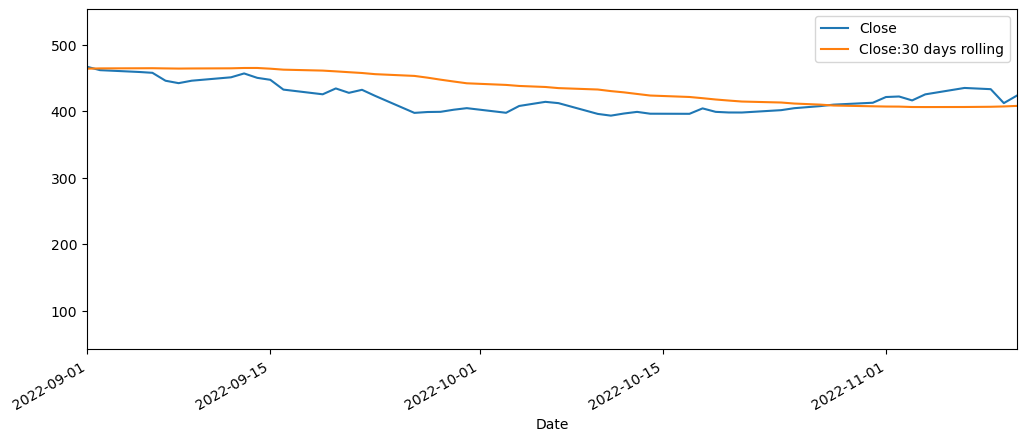

In [38]:
df[['Close','Close:30 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

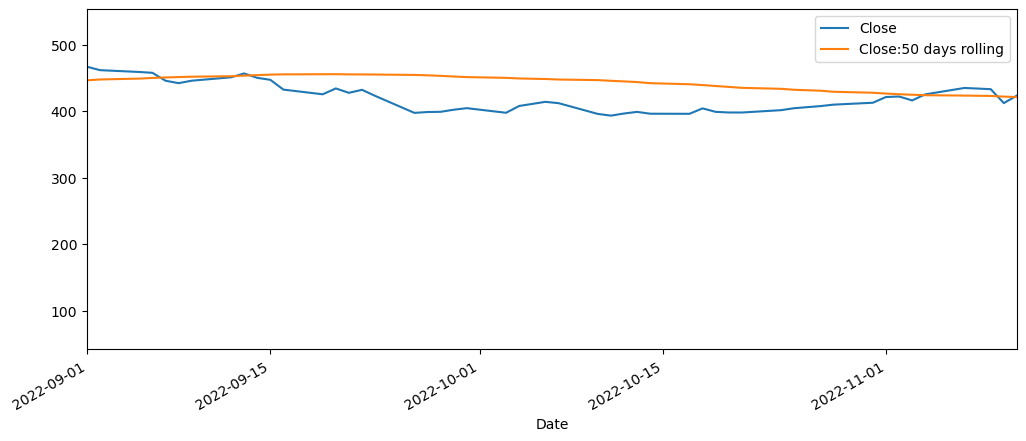

In [39]:
df[['Close','Close:50 days rolling']].plot(xlim=['2022-09-01','2022-11-11'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

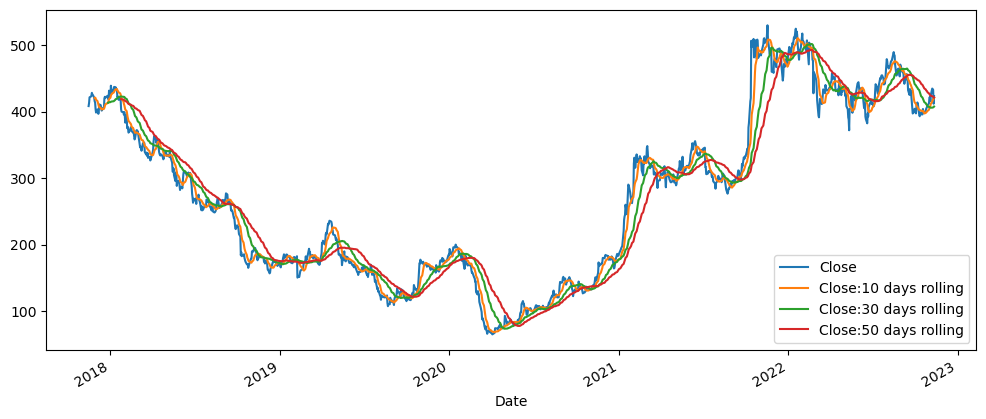

In [40]:
df[['Close','Close:10 days rolling','Close:30 days rolling','Close:50 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

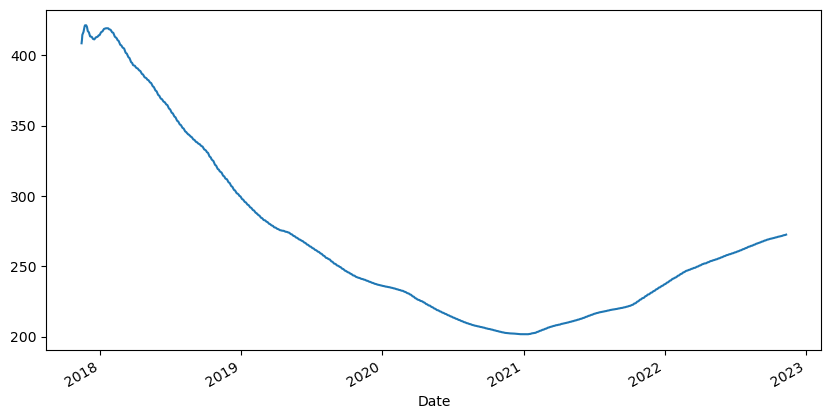

In [41]:
# cumulative moving average(here I use for only open stock)
# use expanding
df['Close'].expanding().mean().plot(figsize=(10,5))

In [42]:
#  exponential moving average
df['EMA_0.1'] = df['Close'].ewm(alpha=0.1, adjust=False).mean()
df['EMA_0.3'] = df['Close'].ewm(alpha=0.3, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

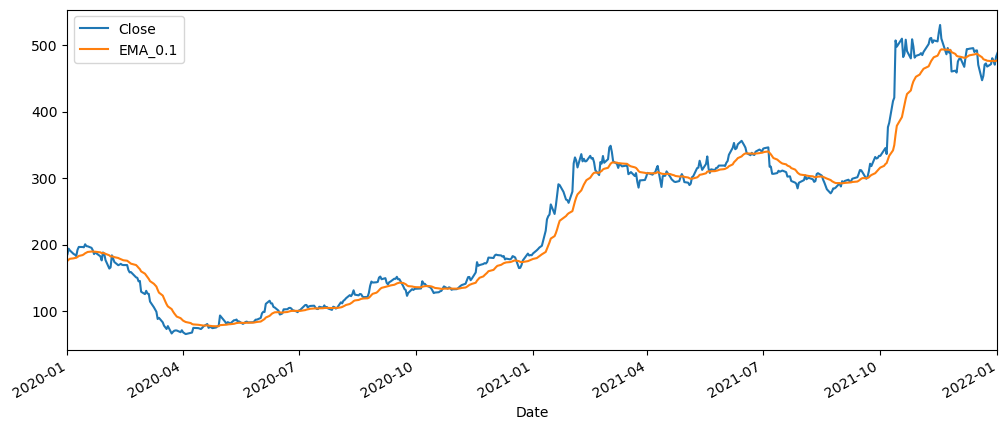

In [43]:
df[['Close','EMA_0.1']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

<AxesSubplot:xlabel='Date'>

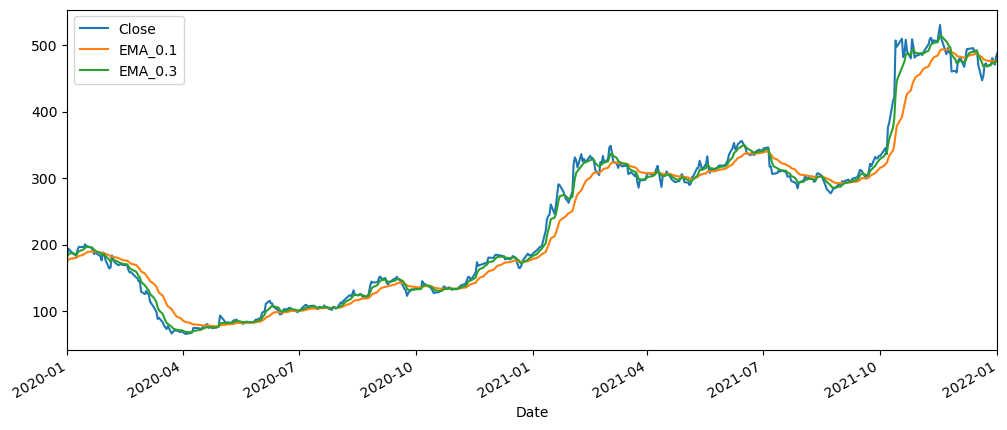

In [44]:
df[['Close','EMA_0.1','EMA_0.3']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

# STAT MODEL WITH ARIMA

In [45]:
# since it is seasonal data we are going to use dickey fuller test
from statsmodels.tsa.stattools import adfuller

In [46]:
# H0 : It is not stationary
# H1 : It is stationary

In [47]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

#strong evidence against the null hypothesis, reject the null hypothesis. 
#Data has no unit root and is stationary

#weak evidence against null hypothesis, time series has a unit root, 
#indicating it is non-stationary 

In [48]:
df1=pd.read_csv('TATAMOTORS_data.csv')
df1.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
1,2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2,2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428


In [49]:
df1.shape

(1233, 7)

In [50]:
df1.set_index('Date', inplace=True)

In [51]:
df1.index = pd.to_datetime(df.index, format = '%Y/%m/%d')

In [52]:
df1

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407
...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443


In [53]:
adf_test(df1['Close'])

ADF Statistics: -1.1490244440559358
p- value: 0.6951311109960278
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [54]:
## Use Techniques Differencing --> 
# one dayy differencing to convery into stationary data
# we can;t work with seasonal data
df1['first_diff_Close']=df1['Close']-df1['Close'].shift(1)

In [55]:
df1.head()

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,4.800018
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,8.349976
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153,1.200012
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407,1.250000


In [56]:
adf_test(df1['first_diff_Close'].dropna())

ADF Statistics: -9.125982827214441
p- value: 3.112876744456458e-15
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [57]:
# now time to determine p(pacf) and q(acf) value
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

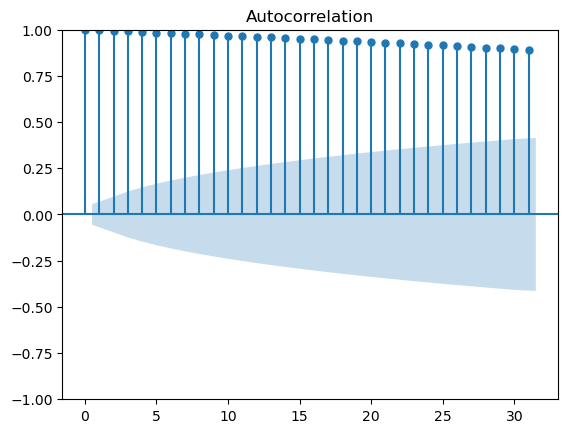

In [58]:
acf = plot_acf(df1["Close"].dropna())

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


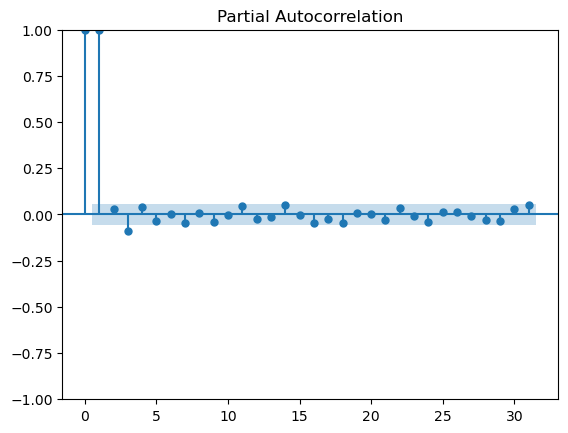

In [59]:
acf12 = plot_pacf(df1["Close"].dropna())

In [60]:
df1.shape

(1233, 7)

In [61]:
### split train and test data
df1.head(3)

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,4.800018
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,8.349976


In [62]:
df1.tail(3)

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,-1.850006
2022-11-10,420.500000,420.549988,409.200012,412.200012,412.200012,26251660,-20.949982
2022-11-11,420.000000,425.500000,414.700012,423.500000,423.500000,19296401,11.299988


<AxesSubplot:xlabel='Date'>

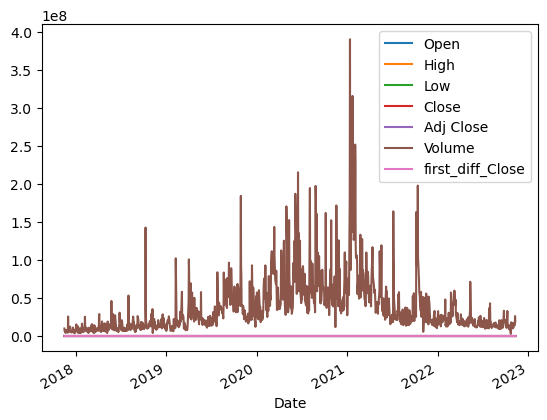

In [63]:
df1.plot()

In [64]:
from datetime import datetime,timedelta
train_dataset_end=datetime(2021,12,1)
test_dataset_end=datetime(2022,11,11)


In [65]:
train_data=df1[:train_dataset_end]
test_data=df1[train_dataset_end+timedelta(days=1):test_dataset_end]

In [66]:
train_data

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2017-11-15,414.299988,417.549988,407.000000,408.649994,408.649994,9867270,NaN
2017-11-16,411.350006,415.899994,411.350006,413.450012,413.450012,6291441,4.800018
2017-11-17,419.450012,423.450012,417.000000,421.799988,421.799988,6191428,8.349976
2017-11-20,421.000000,425.700012,420.100006,423.000000,423.000000,4051153,1.200012
2017-11-21,424.450012,430.000000,422.500000,424.250000,424.250000,6745407,1.250000
...,...,...,...,...,...,...,...
2021-11-25,490.799988,495.149994,486.500000,492.750000,492.750000,15336539,4.100006
2021-11-26,486.000000,486.750000,458.000000,460.200012,460.200012,51787989,-32.549988
2021-11-29,457.000000,470.750000,443.100006,461.450012,461.450012,42819150,1.250000


In [67]:
test_data

,Open,High,Low,Close,Adj Close,Volume,first_diff_Close
Date,,,,,,,
2021-12-02,479.399994,480.450012,471.700012,479.100006,479.100006,21012008,3.850006
2021-12-03,480.000000,484.700012,477.299988,480.100006,480.100006,20948900,1.000000
2021-12-06,480.100006,480.899994,466.000000,467.200012,467.200012,17473075,-12.899994
2021-12-07,476.850006,484.899994,471.000000,481.799988,481.799988,21280797,14.599976
2021-12-08,484.500000,495.950012,483.500000,493.899994,493.899994,20581817,12.100006
...,...,...,...,...,...,...,...
2022-11-04,418.200012,426.000000,416.899994,425.350006,425.350006,12277023,9.100006
2022-11-07,428.250000,437.500000,428.250000,435.000000,435.000000,15058076,9.649994
2022-11-09,439.200012,441.200012,432.000000,433.149994,433.149994,14471443,-1.850006


In [68]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(df1['Close'],order=(2,1,2))

model_fit=model.fit()

model_fit.summary()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1233
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4301.810
Date:                Thu, 29 Dec 2022   AIC                           8613.620
Time:                        17:22:06   BIC                           8639.202
Sample:                             0   HQIC                          8623.244
                               - 1233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3269      0.466     -0.702      0.483      -1.240       0.586
ar.L2          0.4576      0.431      1.062      0.288      -0.387       1.302
ma.L1          0.3037      0.475      0.640      0.522      -0.627       1.234
ma.L2         -0.4092      0.423     -0.967      0.334      -1.239       0.420
sigma2        63.1552      1.228     51.442      0.000      60.749      65.561
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):              9343.14
Prob(Q):                              0.71   Prob(JB):                         0.00
Heteroskedasticity (H):               3.21   Skew:                             0.93
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [69]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

2021-12-02 00:00:00
2022-11-11 00:00:00


In [70]:
pred=model_fit.predict(start=pred_start_date, end =pred_end_date)
residuals=test_data['Close']-pred

In [71]:
pred

Date
2021-12-02    473.192025
2021-12-03    481.090491
2021-12-06    478.816639
2021-12-07    468.751509
2021-12-08    479.840588
                 ...    
2022-11-04    416.345852
2022-11-07    424.965992
2022-11-09    435.373203
2022-11-10    433.389801
2022-11-11    412.675434
Name: predicted_mean, Length: 235, dtype: float64

In [72]:
residuals

Date
2021-12-02     5.907981
2021-12-03    -0.990485
2021-12-06   -11.616627
2021-12-07    13.048479
2021-12-08    14.059406
                ...    
2022-11-04     9.004154
2022-11-07    10.034008
2022-11-09    -2.223209
2022-11-10   -21.189789
2022-11-11    10.824566
Length: 235, dtype: float64

<AxesSubplot:ylabel='Density'>

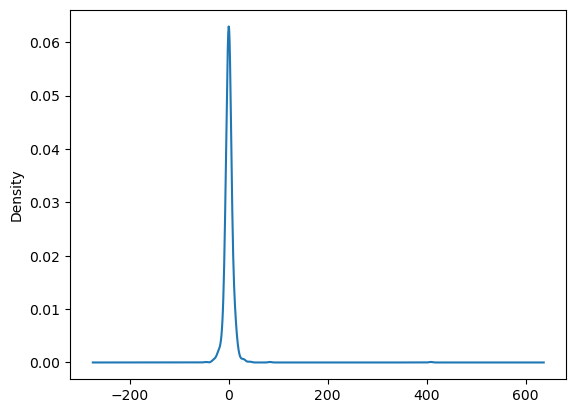

In [74]:
model_fit.resid.plot(kind='kde')

In [75]:
test_data['Predicted_ARIMA_close']=pred

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_17116\4048640912.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA_close']=pred


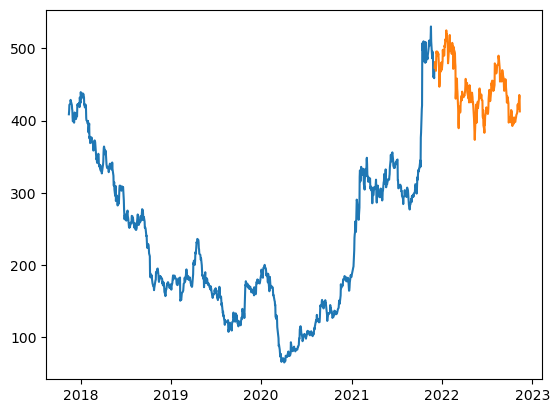

In [85]:
plt.plot(train_data['Close'])
plt.plot(test_data['Predicted_ARIMA_close'])
#test_data[['Close','Predicted_ARIMA_close']].plot()
#.plot(figsize=(15,10))

<AxesSubplot:xlabel='Date'>

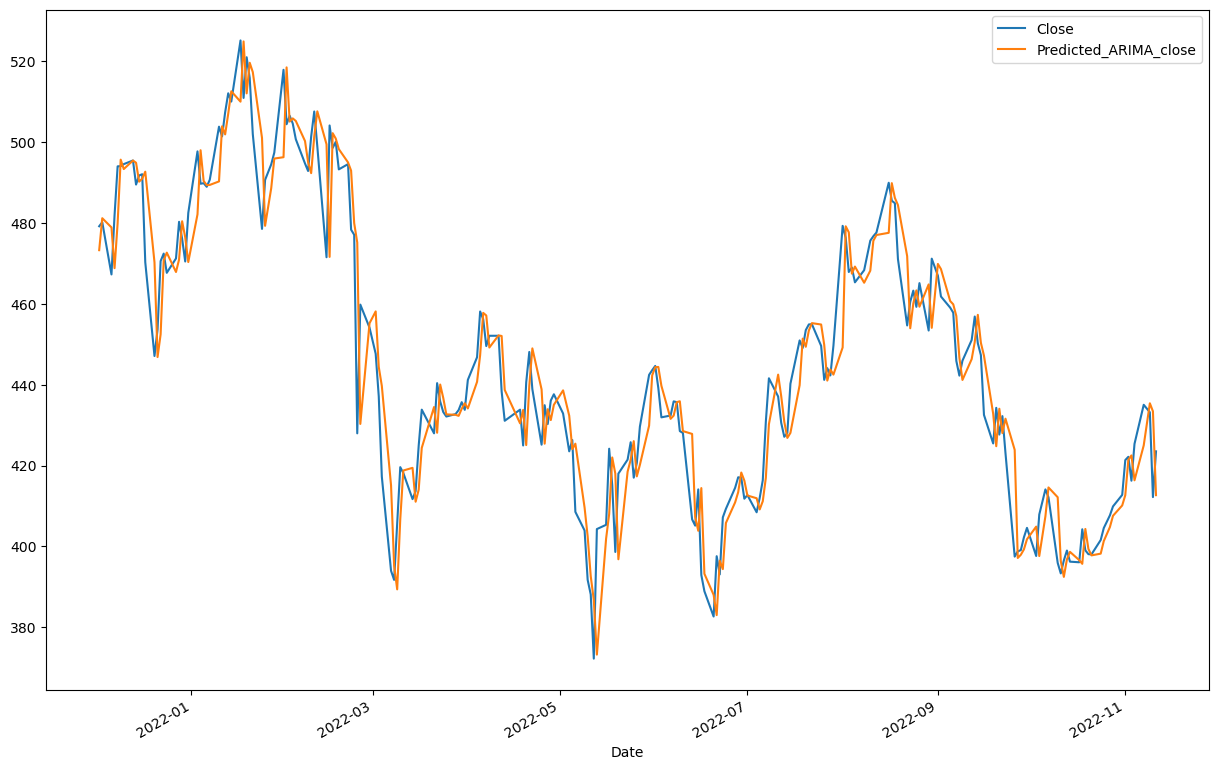

In [80]:
test_data[['Close','Predicted_ARIMA_close']].plot(figsize=(15,10))

In [86]:
pred

Date
2021-12-02    473.192025
2021-12-03    481.090491
2021-12-06    478.816639
2021-12-07    468.751509
2021-12-08    479.840588
                 ...    
2022-11-04    416.345852
2022-11-07    424.965992
2022-11-09    435.373203
2022-11-10    433.389801
2022-11-11    412.675434
Name: predicted_mean, Length: 235, dtype: float64

In [87]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [88]:
mse= mean_squared_error(pred,test_data['Close'])
mse

106.24088824915414

In [89]:
rmse= sqrt(mean_squared_error(pred,test_data['Close']))
rmse

10.307322069730533

In [90]:
test_data['Close'].mean()
# as rmse is very lesser than mean then our model is a good model

445.3608511404254

In [94]:
##prediction
pred1_start_date=test_data.index[-1]
pred1_end_date='2023-02-20 00:00:00'
print(pred1_start_date)
print(pred1_end_date)

2022-11-11 00:00:00
2023-02-20 00:00:00


In [97]:
index_future_dates = pd.date_range(start='2022-11-11',end='2023-02-20')
pred1=model_fit.predict(start=len(df1),end=len(df1)+101)
pred1.index=index_future_dates
# residuals1=test_data['Close']-pred1

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [98]:
pred1

2022-11-11    422.177199
2022-11-12    423.351541
2022-11-13    422.362285
2022-11-14    423.223097
2022-11-15    422.488976
                 ...    
2023-02-16    422.831753
2023-02-17    422.831753
2023-02-18    422.831753
2023-02-19    422.831753
2023-02-20    422.831753
Freq: D, Name: predicted_mean, Length: 102, dtype: float64

dff=pd.DataFrame(pred1)

df.index.to_datetime()

dff['index'].plot(figsize=(10,5))

dff['predicted_mean'].plot(xlim=(['2022-11-11','2022-12-20']),figsize=(10,5))

<AxesSubplot:>

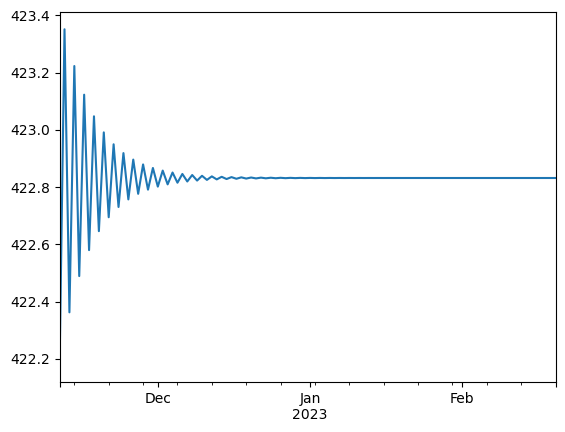

In [99]:
pred1.plot()

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [101]:
print('r2_score', r2_score(test_data['Close'],pred))

r2_score 0.9114726240974951


In [ ]:
df

In [ ]:
df.dropna(inplace=True)
df

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
rmse_2days= sqrt(mean_squared_error(df['Close:2 days rolling'],df['Close']))
rmse_2days

In [ ]:
print('r2_score', r2_score(df['Close'],df['Close:2 days rolling']))

In [ ]:
rmse_5days= sqrt(mean_squared_error(df['Close:5 days rolling'],df['Close']))
rmse_5days

In [ ]:
rmse_7days= sqrt(mean_squared_error(df['Close:5 days rolling'],df['Close']))
rmse_7days

In [ ]:
rmse_10days= sqrt(mean_squared_error(df['Close:10 days rolling'],df['Close']))
rmse_10days

In [ ]:
rmse_30days= sqrt(mean_squared_error(df['Close:30 days rolling'],df['Close']))
rmse_30days

In [ ]:
rmse_50days= sqrt(mean_squared_error(df['Close:50 days rolling'],df['Close']))
rmse_50days

In [ ]:
rmse_EMA01 = sqrt(mean_squared_error(df['EMA_0.1'],df['Close']))
rmse_EMA01

In [ ]:
rmse_EMA_03= sqrt(mean_squared_error(df['EMA_0.3'],df['Close']))
rmse_EMA_03

# Machine Learning

In [ ]:
df2=pd.read_csv('TATAMOTORS_data.csv')

df2.set_index('Date', inplace=True)

df2.index = pd.to_datetime(df2.index, format = '%Y/%m/%d')

In [ ]:
df2=df2.iloc[:,:4]

In [ ]:
df2.head()

x=np.array(df2.index).reshape(-1,1)
y=df2['Close']

In [ ]:
x = df2.iloc[:, :-1]
y = df2.iloc[:, -1]

In [ ]:
x

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

# Linear Reression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

y_pred_test = lr.predict(x_test)

In [ ]:
lr.coef_

In [ ]:
lr.intercept_

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('MAE', mean_absolute_error(y_test,y_pred_test))
print('MSE', mean_squared_error(y_test,y_pred_test))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test)))
print('r2_score', r2_score(y_test,y_pred_test))

# SVR

In [ ]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(x_train, y_train)

y_pred_test_svm = regressor.predict(x_test)

In [ ]:
print('MAE', mean_absolute_error(y_test,y_pred_test_svm))
print('MSE', mean_squared_error(y_test,y_pred_test_svm))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test_svm)))
print('r2_score', r2_score(y_test,y_pred_test_svm))

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
regressor_dt = DecisionTreeRegressor(random_state = 0)
regressor_dt.fit(x, y)

y_pred_test_dt = regressor_dt.predict(x_test)

In [ ]:
print('MAE', mean_absolute_error(y_test,y_pred_test_dt))
print('MSE', mean_squared_error(y_test,y_pred_test_dt))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test_dt)))
print('r2_score', r2_score(y_test,y_pred_test_dt))

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor_rf = RandomForestRegressor(n_estimators = 80, random_state = 0)
regressor_rf.fit(x, y)

y_pred_test_rf = regressor_rf.predict(x_test)

In [ ]:
print('MAE', mean_absolute_error(y_test,y_pred_test_rf))
print('MSE', mean_squared_error(y_test,y_pred_test_rf))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test_rf)))
print('r2_score', r2_score(y_test,y_pred_test_rf))

# Lasso Regression

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso=Lasso()

parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(x,y)

In [ ]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

In [ ]:
prediction_lasso=lasso_regressor.predict(x_test)

In [ ]:
print('MAE', mean_absolute_error(y_test,prediction_lasso))
print('MSE', mean_squared_error(y_test,prediction_lasso))
print('RMSE', np.sqrt(mean_squared_error(y_test,prediction_lasso)))
print('r2_score', r2_score(y_test,prediction_lasso))

# Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(x,y)

In [ ]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

In [ ]:
prediction_ridge=ridge_regressor.predict(x_test)

In [ ]:
print('MAE', mean_absolute_error(y_test,prediction_ridge))
print('MSE', mean_squared_error(y_test,prediction_ridge))
print('RMSE', np.sqrt(mean_squared_error(y_test,prediction_ridge)))
print('r2_score', r2_score(y_test,prediction_ridge))